# Tax-Loss Harvesting — lot-level engine, cohort inference, rate grid 🧾

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Who_gets_zero%3F: Confirmed](https://img.shields.io/badge/Who_gets_zero%3F-Confirmed-8b949e?style=flat-square)

**Claim under test:** systematically harvesting losses into a twin fund adds **0.3–1%/yr** of after-tax alpha (Wealthfront/Betterment; Chaudhuri-Burnham-Lo 2020 find ~1.08%/yr at *stock level*).

**Engine spec** (single broad-index implementation, the plain robo setup):
* SPY daily **total-return** closes 1993-01-29 → 2026-06-30 (as-of; June 2026 last complete month). Twin equivalence justified against IVV.
* **Lot-level accounting** — every purchase (lump sum, monthly contribution, harvest repurchase, reinvested tax saving) opens a lot with its own basis + clock.
* Daily check: lot below basis by > **1%** and held ≥ **31 calendar days** (wash-sale-safe; two-twin routing) → sold at the **next close** (exactly ONE execution lag), loss classified ST (< 366 d) / LT, tax saving = loss × rate, **reinvested immediately** with the proceeds into the twin.
* Costs: **2 bps one-way × traded NAV** on every leg (harvest sell, rebuy, terminal sale). No borrow (long-only, fully invested throughout).
* Terminal: both books liquidate and pay per-lot CGT (LT if ≥ 366 d), losses credit symmetrically; `step_up=True` zeroes terminal tax on both books.
* **Stated assumptions:** harvested losses fully usable against gains taxed at the ST/LT pair (the $3,000 ordinary-income cap never binds — bracketed by the 15/15 and 0/0 rows); SPY↔IVV treated as *not substantially identical* (industry practice, never formally IRS-blessed).

> 💡 **In plain words.** We rebuild a robo-advisor's daily harvesting bot with real tax-lot bookkeeping, run it over 33 years of S&P 500 history, and then run the *same market* through different tax brackets to see whose money the "alpha" really is.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tax_loss_harvesting import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY, IVV = data.load_real()
else:
    SPY = IVV = None
print("real SPY cache present:", HAVE_REAL,
      "| days:", (0 if SPY is None else len(SPY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-01-29', 'end': '2026-06-30', 'n_days': 8411, 'years': 33.4, 'fingerprint': 'cb2440086a51', 'twin_corr': 0.9932, 'twin_gap_bps': 0.01, 'twin_te_bps': 223, 'twin_days': 6565, 'lump_harvests': 0, 'lump_alpha': 0.0, 'grid': [('35/15 (top bracket, ST offsets)', 13.1, 4.49, 667), ('24/15 (middle bracket)', 8.8, 3.0, 667), ('15/15 (deferral only)', 5.4, 1.82, 667), ('35/15 + step-up at death', 13.9, 4.75, 667), ('0/0 (0% bracket — myth check)', -0.4, -0.13, 667), ('0/0 + step-up (low-bracket donor)', -0.4, -0.13, 667)], 'harvested_total': 55216, 'st_share': 88.5, 'tax_saved': 18057, 'term_tax_tlh': 544694, 'term_tax_bh': 511804, 'n_cohorts': 94, 'co_mean': 46.0, 'co_median': 23.5, 'co_sd': 53.9, 'co_min': -0.4, 'co_max': 189.0, 'hac_t': 2.88, 'hac_lag': 40, 'share_pos': 73.4, 'zero_harvest': 24, 'best_start': '2007-10-01', 'worst_start': '2010-10-01', 'decade_means': '1990s +13.2, 2000s +90.8, 2010s +12.5 bps/yr', 'co_grid': [('35/15', 46.0, 23.5, 2.88), ('24/15', 27.5, 14.7, 2.78), ('15/15', 12.3, 6.2, 2.42)], 'bear_mean': 2.23, 'calm_mean': 0.16, 'welch_t': 2.72, 'welch_dof': 6.1, 'bear_years': (2000, 2001, 2002, 2008, 2009, 2020, 2022), 'rich_years': '2008: 4.80%, 2002: 4.29%, 2009: 2.95%, 2001: 2.93%, 1994: 1.33%, 2003: 0.90%', 'decay': [6.57, 3.19, 2.58, 1.81, 1.6, 0.46, 0.19, 0.15, 0.15, 0.17], 'decay_tail': 0.17, 'thresholds': [(0.5, 45.7, 2.94, 4.3), (1.0, 46.0, 2.88, 4.3), (5.0, 48.8, 2.93, 2.5)], 'syn': [(0.02, 0.09, 0.4, -0.02), (0.18, 47.0, 47.7, -2.67), (0.35, 128.45, 104.5, -4.33)]}


real SPY cache present: True | days: 8411


## 0 · Data stamp + twin-fund equivalence

The wash-sale-safe swap only keeps exposure unchanged if the twin really is the same exposure. SPY vs IVV daily returns:

In [2]:
if HAVE_REAL:
    from quantlab import repro
    print(repro.data_stamp('SPY total-return close', SPY.to_frame('SPY'),
                           asof=data.AS_OF))
    tc = data.twin_check(SPY, IVV)
    print(f"SPY vs IVV ({tc['n_days']:,} common days): corr {tc['corr']:.4f} | "
          f"mean gap {tc['gap_ann_bps']:+.2f} bps/yr | "
          f"tracking-diff vol {tc['te_ann_bps']:.0f} bps/yr")
else:
    print('cache missing — see docs/results.md (fingerprint', R['fingerprint'], ')')


[data] SPY total-return close: 8,411 rows  1993-01-29 -> 2026-06-30  as-of 2026-06-30  fingerprint=cb2440086a51
SPY vs IVV (6,565 common days): corr 0.9932 | mean gap +0.01 bps/yr | tracking-diff vol 223 bps/yr


Correlation **0.9932** and a mean return gap of **+0.01 bps/yr** — economically the same asset (the 223 bps/yr daily tracking noise is close-timestamp jitter that nets out). We therefore run ONE price series and let the swap change only the tax lots — so the measured delta is **pure tax timing + costs**, uncontaminated by tracking luck.

> 💡 **In plain words.** SPY and IVV are two wrappers around the same 500 stocks. Selling one and buying the other keeps your market ride identical — only the tax paperwork changes.

## 1 · The full-period runs — lock-up punchline + the rate grid

First the two 33-year investors: the 1993 **lump sum** (never harvests again after month one — SPY never revisits its 1993 basis) and the steady **contributor** ($10k + $1k/month), whose fresh lots keep the machine fed. Then the same contributor tape through the rate grid.

In [3]:
if HAVE_REAL:
    rl = st.after_tax_alpha(SPY, st_rate=0.35, lt_rate=0.15)
    print(f"lump sum $100k, {rl['years']:.1f}y at 35/15: "
          f"{rl['h']['n_harvests']} harvests, alpha {rl['alpha_bps']:+.1f} bps/yr")
    print()
    for stt, ltt, su, lab in [(0.35,0.15,False,'35/15'), (0.24,0.15,False,'24/15'),
                              (0.15,0.15,False,'15/15'), (0.35,0.15,True,'35/15+step-up'),
                              (0.0,0.0,False,'0/0'), (0.0,0.0,True,'0/0+step-up')]:
        rr = st.after_tax_alpha(SPY, initial=10_000, monthly_contrib=1_000,
                                st_rate=stt, lt_rate=ltt, step_up=su)
        print(f"contributor {lab:<14s} alpha {rr['alpha_bps']:+6.1f} bps/yr | "
              f"uplift {rr['uplift_pct']:+6.2f}% | harvests {rr['h']['n_harvests']}")
else:
    for lab, a, u, n in R['grid']:
        print(f'{lab:<36s} {a:+6.1f} bps/yr  {u:+6.2f}%  ({n} harvests)')


lump sum $100k, 33.4y at 35/15: 0 harvests, alpha +0.0 bps/yr



contributor 35/15          alpha  +13.1 bps/yr | uplift  +4.49% | harvests 667


contributor 24/15          alpha   +8.8 bps/yr | uplift  +3.00% | harvests 667


contributor 15/15          alpha   +5.4 bps/yr | uplift  +1.82% | harvests 667


contributor 35/15+step-up  alpha  +13.9 bps/yr | uplift  +4.75% | harvests 667


contributor 0/0            alpha   -0.4 bps/yr | uplift  -0.13% | harvests 667


contributor 0/0+step-up    alpha   -0.4 bps/yr | uplift  -0.13% | harvests 667


Same 667 harvests in every contributor row — only the rates move the payoff:

| rate pair (ST/LT) | after-tax alpha (bps/yr) | terminal uplift |
|---|--:|--:|
| 35/15 (top bracket, ST offsets) | **+13.1** | +4.49% |
| 24/15 (middle bracket) | **+8.8** | +3.00% |
| 15/15 (deferral only) | **+5.4** | +1.82% |
| 35/15 + step-up at death | **+13.9** | +4.75% |
| 0/0 (0% bracket — myth check) | **-0.4** | -0.13% |
| 0/0 + step-up (low-bracket donor) | **-0.4** | -0.13% |

* the ST/LT **rate arbitrage** (35→15) is worth ~7.7 bps/yr on top of the ~5.4 bps/yr pure-**deferral** value (the 15/15 row);
* **0/0 banks −0.4 bps/yr** — exactly the trading costs. The engine cannot manufacture value without a tax rate: the myth-check null on the *real* tape;
* **step-up at death** turns deferral into forgiveness — but only for brackets that deduct something (+13.9 vs +13.1 at 35/15; still −0.4 at 0/0).

Detail at 35/15: harvested **$55,216** of losses (**88.5% short-term** — harvest resets the clock, so re-harvests are almost always ST), tax savings reinvested **$18,057**, terminal tax **$544,694** (TLH) vs **$511,804** (B&H) — TLH *repays* part of its deductions at liquidation, as the arithmetic demands.

> 💡 **In plain words.** The bot deducts at ~35 cents per dollar of loss today and repays at ~15 cents at the end — pocketing the 20-cent spread plus decades of interest-free use of the money. Set the rates to zero and the bot just burns commissions.

## 2 · The Signal axis — 94 overlapping 10-year cohorts

One lump-sum cohort per quarter-start (1993Q1 → 2016Q2 starts), each run 10 years at 35/15. Overlap = 39 quarters, so the mean's *t* uses **Newey-West lag 40**.

cohorts 94 | mean +46.0 | median +23.5 | sd 53.9 | min -0.4 | max +189.0 bps/yr
HAC t (lag 40) = +2.88 | share>0 73.4% | zero-harvest cohorts 24


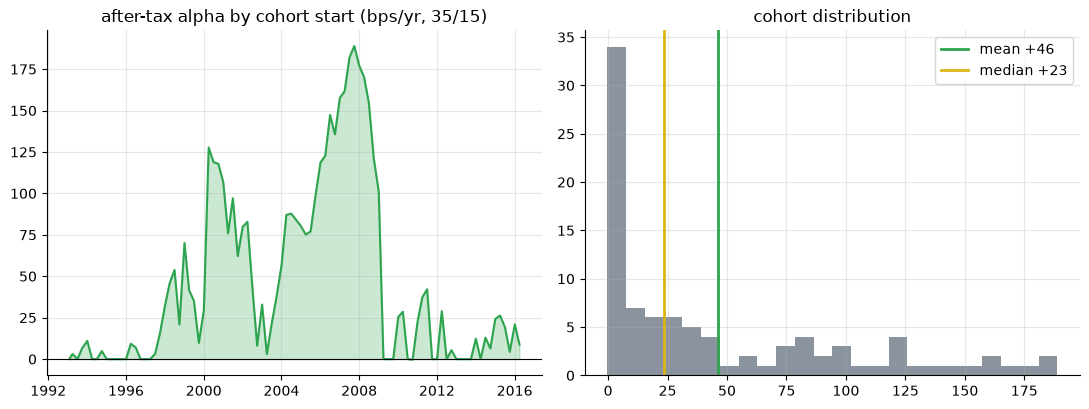

In [4]:
if HAVE_REAL:
    co = st.cohort_alphas(SPY, horizon_years=10, st_rate=0.35, lt_rate=0.15)
    a = co['alpha_bps'].to_numpy()
    print(f'cohorts {len(co)} | mean {a.mean():+.1f} | median {np.median(a):+.1f} | '
          f'sd {a.std(ddof=1):.1f} | min {a.min():+.1f} | max {a.max():+.1f} bps/yr')
    print(f'HAC t (lag 40) = {st.nw_tstat(a, 40):+.2f} | share>0 '
          f'{100*(a>0).mean():.1f}% | zero-harvest cohorts '
          f"{(co['n_harvests']==0).sum()}")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
    ax1.plot(co.index, a, color=GREEN)
    ax1.fill_between(co.index, 0, a, color=GREEN, alpha=.25)
    ax1.axhline(0, color='k', lw=.8)
    ax1.set_title('after-tax alpha by cohort start (bps/yr, 35/15)')
    ax2.hist(a, bins=24, color=GREY)
    ax2.axvline(a.mean(), color=GREEN, lw=2, label=f'mean {a.mean():+.0f}')
    ax2.axvline(np.median(a), color=AMBER, lw=2, label=f'median {np.median(a):+.0f}')
    ax2.legend(); ax2.set_title('cohort distribution')
    plt.tight_layout()
else:
    print('cache missing — quoting R: mean', R['co_mean'], 'HAC t', R['hac_t'])


**Mean +46.0 bps/yr, HAC *t* (lag 40) = +2.88** — the mechanical after-tax delta clears the desk's *t* ≥ 2 bar on the real tape. But look at the *shape*: median **+23.5**, **24 of 94** cohorts never harvest at all (start into a bull → basis locks immediately), max **+189** for cohorts that ride into 2000–02 or 2008. Cohorts starting **2007-10-01** did best; **2010-10-01** worst (-0.4 — a hair below zero: costs plus an unlucky ST/LT flip). By start decade: 1990s +13.2, 2000s +90.8, 2010s +12.5 bps/yr.

**Cohort rate grid** (same sweep at other rate pairs — recomputed in `examples/verify.py`):

| rates (ST/LT) | mean (bps/yr) | median | HAC *t* |
|---|--:|--:|--:|
| 35/15 | **+46.0** | +23.5 | +2.88 |
| 24/15 | **+27.5** | +14.7 | +2.78 |
| 15/15 | **+12.3** | +6.2 | +2.42 |

Significant at every rate pair — and the *magnitude* scales with the rate spread, as arithmetic must.

> 💡 **In plain words.** Whether harvesting pays 0, 20 or 190 bps a year depends almost entirely on *when you started* — you need the market to hand you losses. The average is statistically solid; the typical experience is half the headline.

## 3 · Path dependence + decay — where and when the harvest lives

harvest yield: bear years 2.23%/yr (n=7) vs calm 0.16%/yr (n=27) | Welch t = +2.72 (dof 6.1)
richest years: 2008: 4.80%, 2002: 4.29%, 2009: 2.95%, 2001: 2.93%, 1994: 1.33%, 2003: 0.90%


Text(0.5, 1.0, 'Basis lock-up: the harvest decays 6.6% (y1) → 0.17%/yr (y7-10) — avg across 94 cohorts')

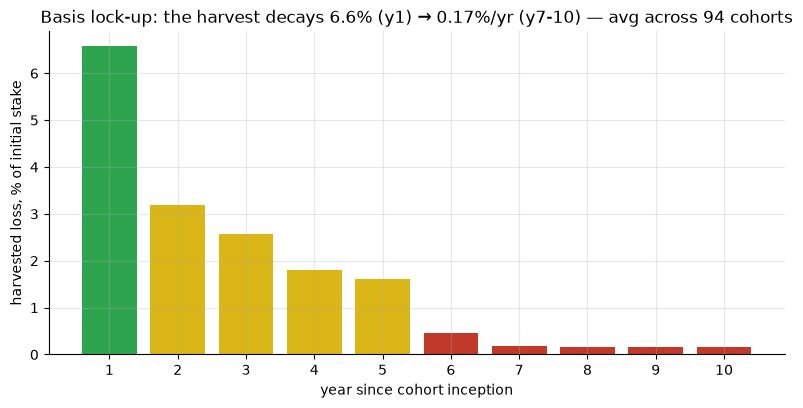

In [5]:
if HAVE_REAL:
    r35 = st.after_tax_alpha(SPY, initial=10_000, monthly_contrib=1_000,
                             st_rate=0.35, lt_rate=0.15)
    hy = st.harvest_yield_by_year(r35['h'])
    bear = hy[hy.index.isin(R['bear_years'])].to_numpy()
    calm = hy[~hy.index.isin(R['bear_years'])].to_numpy()
    tw, dof = st.welch_t(bear, calm)
    print(f'harvest yield: bear years {bear.mean():.2f}%/yr (n={len(bear)}) vs '
          f'calm {calm.mean():.2f}%/yr (n={len(calm)}) | Welch t = {tw:+.2f} '
          f'(dof {dof:.1f})')
    rich = hy.sort_values(ascending=False).head(6)
    print('richest years:', ', '.join(f'{int(y)}: {v:.2f}%' for y, v in rich.items()))
else:
    print('bear', R['bear_mean'], 'vs calm', R['calm_mean'], 'Welch t', R['welch_t'])
fig, ax = plt.subplots(figsize=(9.5, 4.2))
yrs = np.arange(1, 11)
ax.bar(yrs, R['decay'], color=[GREEN]+[AMBER]*4+[RED]*5)
ax.set_xticks(yrs); ax.set_xlabel('year since cohort inception')
ax.set_ylabel('harvested loss, % of initial stake')
ax.set_title('Basis lock-up: the harvest decays '
             f"{R['decay'][0]:.1f}% (y1) → {R['decay_tail']:.2f}%/yr (y7-10) — "
             'avg across 94 cohorts')


Bear years harvest **2.23%** of NAV per year vs **0.16%** in calm years — **Welch *t* = +2.72** (dof 6.1, n = 7 vs 27 calendar years). The harvest is a bear-market crop: 2008 (4.80%), 2002 (4.29%), 2009 (2.95%), 2001 (2.93%) dwarf everything since — even 2020 and 2022 yield ~0.1% because by then the contributor's NAV is dominated by old, deeply-appreciated lots (2022's drawdown never got below most of the 2010s basis).

And the decay curve is the industry's quiet footnote: **6.57%** of the stake harvested in year 1, **0.17%/yr** by years 7–10 — a ~40× fade. The 1993 lump sum harvests **zero** for 33 years. Without fresh cash, the machine retires itself.

> 💡 **In plain words.** The bot only earns when prices sit below what *you* paid — which happens early, in crashes, or right after new deposits. A long-held account in a rising market gives it nothing to do.

## 4 · Robustness — the harvest threshold

Cohort sweep at other trigger levels (recomputed in `examples/verify.py`):

| harvest when loss > | cohort mean (bps/yr) | HAC *t* | harvests/cohort |
|---|--:|--:|--:|
| 0.5% | +45.7 | +2.94 | 4.3 |
| 1.0% | +46.0 | +2.88 | 4.3 |
| 5.0% | +48.8 | +2.93 | 2.5 |

The alpha is flat in the trigger (45.7–48.8 bps, *t* = 2.88–2.94): with 2 bps legs and a 35% deduction, almost any loss is worth harvesting, and the result is not an artefact of where we drew the 1% line.

## 5 · Synthetic control — the volatility knob (machinery proof)

Deterministic GBM worlds, **20 seeds per cell** (single-seed baselines are banned on this desk). TLH alpha must rise with the planted volatility knob — volatility is what serves up harvestable drawdowns — and must sit at ~zero minus costs when rates are 0/0, whatever the path.

       alpha_bps_35_15  alpha_sd  alpha_bps_rates0
sigma                                             
0.02              0.09      0.42             -0.02
0.18             47.00     47.67             -2.67
0.35            128.45    104.53             -4.33


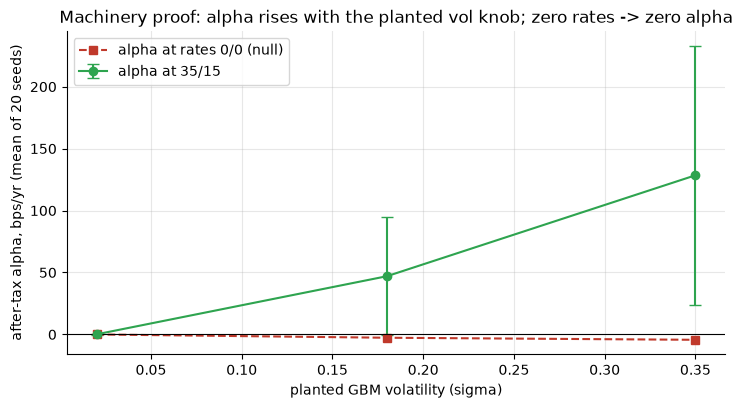

In [6]:
ctl = st.synthetic_control(sigmas=(0.02, 0.18, 0.35), n_seeds=20)
print(ctl.round(2))
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.errorbar(ctl.index, ctl['alpha_bps_35_15'], yerr=ctl['alpha_sd'],
            fmt='o-', color=GREEN, capsize=4, label='alpha at 35/15')
ax.plot(ctl.index, ctl['alpha_bps_rates0'], 's--', color=RED,
        label='alpha at rates 0/0 (null)')
ax.axhline(0, color='k', lw=.8)
ax.set_xlabel('planted GBM volatility (sigma)')
ax.set_ylabel('after-tax alpha, bps/yr (mean of 20 seeds)')
ax.set_title('Machinery proof: alpha rises with the planted vol knob; '
             'zero rates -> zero alpha')
ax.legend()


σ = 0.02 → **+0.09** bps/yr (no drawdowns, nothing to harvest); σ = 0.18 → **+47.0**; σ = 0.35 → **+128.4** — and the 0/0-rate null sits at **-0.02 to -4.33** bps/yr (the cost drag) at every σ. The engine detects exactly the effect it should and cannot manufacture value without a tax rate. *(Machinery proof only — never cited in support of the Signal stamp.)*

## Verdict

* **Signal — REAL.** Mean after-tax alpha **+46.0 bps/yr** across 94 ten-year cohorts, **HAC *t* = +2.88** (lag 40), robust to threshold (2.88–2.94) and rate pair (2.42–2.78); the 0/0 run banks −0.4 bps/yr, proving the delta is pure tax arithmetic. The advertised **0.3–1%/yr** holds only at the top bracket on the *mean*; the median cohort gets +23.5 bps and the 33-year contributor +13.1.
* **Tradability — FRAGILE.** Costs are trivial and capacity unbounded, but the harvest is front-loaded (6.6% → 0.17%/yr), bear-fed (Welch *t* = +2.72), zero in 24/94 cohorts, needs external ST gains for the headline rate — and a 0.25%/yr robo fee exceeds the median cohort's take.
* **Who gets ZERO? — CONFIRMED.** The 0%-bracket retiree/donor: **−0.4 bps/yr** (pure costs), with or without step-up. The alpha is a private rate arbitrage — it is *your bracket*, monetised.

*Reproduce every number: `python examples/verify.py` · frozen copy: [docs/results.md](../docs/results.md) · literature: [docs/references.md](../docs/references.md). Not investment or tax advice.*